<a href="https://colab.research.google.com/github/marsya505/DataMining/blob/main/Week6-Fuel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving fuel_efficiency_speed.csv to fuel_efficiency_speed (7).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   speed_kmh         20 non-null     int64  
 1   fuel_consumption  20 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 452.0 bytes


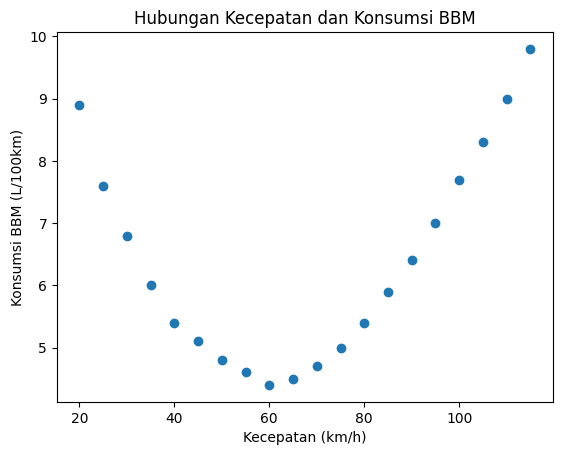

RMSE Training: 0.16936915917924067
RMSE Testing: 0.5614516586136128


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


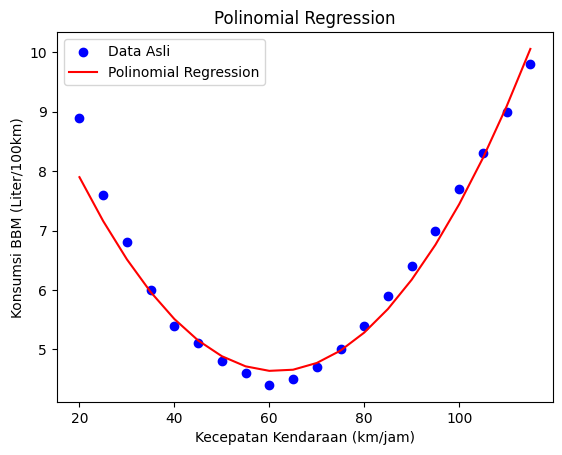

Prediksi konsumsi BBM: 11.119871893797004


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

from google.colab import files
uploaded = files.upload()

data = pd.read_csv("fuel_efficiency_speed.csv")
data.head()

data.info()
data.describe()

plt.scatter(data['speed_kmh'], data['fuel_consumption'])
plt.xlabel("Kecepatan (km/h)")
plt.ylabel("Konsumsi BBM (L/100km)")
plt.title("Hubungan Kecepatan dan Konsumsi BBM")
plt.show()

x = data[['speed_kmh']]
y = data['fuel_consumption']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size= 0.2, random_state=42
)

poly = PolynomialFeatures(degree=2)

x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

model = LinearRegression()
model.fit(x_train_poly, y_train)

y_train_pred = model.predict(x_train_poly)
y_test_pred = model.predict(x_test_poly)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("RMSE Training:", rmse_train)
print("RMSE Testing:", rmse_test)

plt.scatter(x, y, color='blue', label='Data Asli')

x_sorted = np.sort(x.values, axis=0)
x_sorted_poly = poly.transform(x_sorted)

y_sorted_pred = model.predict(x_sorted_poly)

plt.plot(x_sorted, y_sorted_pred, color='red', label='Polinomial Regression')

plt.xlabel("Kecepatan Kendaraan (km/jam)")
plt.ylabel("Konsumsi BBM (Liter/100km)")
plt.title("Polinomial Regression")

plt.legend()
plt.show()

new_speed = np.array([[120]])

new_speed_poly = poly.transform(new_speed)

prediction = model.predict(new_speed_poly)

print("Prediksi konsumsi BBM:", prediction[0])
